In [6]:
import glob
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import warnings
warnings.filterwarnings('ignore')


#function to read eurostats data
def read_and_clean_eurostats(file:str, size:bool=False) -> pd.DataFrame:
    #read from file
    df = pd.read_csv(file, delimiter='\t', dtype = str)
    #expand information
    idvariables = ['datalevel', 'sectorcode', 'variable'] + (['size', 'country'] if size else ['country'])
    df[idvariables] = df.iloc[:,0].str.split(',', expand=True)
    df = df.iloc[:, 1:]

    df_long =  df.melt(
        id_vars=idvariables,
        var_name='year',
        value_name='value'
    )
    #clean strings and values
    df_long = df_long.map(lambda x: x.strip())
    df_long['value'] = pd.to_numeric(df_long['value'].str.replace(r"\D", "", regex=True), errors='coerce')
    df_long['year'] = pd.to_numeric(df_long['year'].str.replace(r"\D", "", regex=True), errors='coerce')
    #drop all that have no correct year type
    df_long = df_long.dropna(subset=['year'])

    return df_long

#function to read klems data
def read_klems_data(file: str, var: str)-> pd.DataFrame:
    df = pd.read_excel(file, sheet_name=var)
    df = df.rename(columns={'nace_r2_code': 'sectorcode', 'nace_r2_name': 'Sector', 'geo_code': 'country'})
    df = df.drop(columns=['var', 'geo_name'], axis=1)

    #make it long
    df = df.melt(['sectorcode', 'country', 'Sector'], var_name='year')
    df['year'] = pd.to_numeric(df['year'])
    df['variable'] = var

    #filter for sectors
    df = df[df['sectorcode'].isin(['C', 'F'])]

    return df


def plot_series(data: pd.DataFrame, country: str, var: str, title: str, category: str = None, ax: Axes = None) -> Axes:
    df = data[(data['country'] == country)]
    
    # Create Axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    # Plot
    sns.lineplot(data=df, x='year', y=var, hue=category, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    
    return ax


In [7]:
#read assets from all klems files
file_list = glob.glob(os.path.join('klems data', "*.xlsx"))
klems = pd.concat([read_klems_data(file, var='I_GFCF') for file in file_list])
assets = klems.rename(columns={'value': 'assets'})
assets


,sectorcode,country,Sector,year,assets,variable
2,C,DE,Manufacturing,1995,71773.000,I_GFCF
21,F,DE,Construction,1995,8114.000,I_GFCF
60,C,DE,Manufacturing,1996,73012.002,I_GFCF
79,F,DE,Construction,1996,6983.000,I_GFCF
118,C,DE,Manufacturing,1997,74272.002,I_GFCF
...,...,...,...,...,...,...
1413,F,EL,Construction,2019,172.000,I_GFCF
1452,C,EL,Manufacturing,2020,2459.400,I_GFCF
1471,F,EL,Construction,2020,180.200,I_GFCF
1510,C,EL,Manufacturing,2021,2460.300,I_GFCF


In [8]:
#read revenue from eurostat data
eurostat = pd.concat([read_and_clean_eurostats('eurostat data/1995-2008 manufacturing 1.tsv'),
                     read_and_clean_eurostats("eurostat data/1995-2008 construction.tsv"),
                     read_and_clean_eurostats("eurostat data/1995-2008 Manufacturing 2.tsv")])
#chagne sector code to code of newere dataset
eurostat['sectorcode'] = np.where(eurostat['sectorcode'] == 'D', 'C', eurostat['sectorcode'])

eurostat = pd.concat([eurostat, 
                    read_and_clean_eurostats("eurostat data/2005-2020 construction.tsv"),
                    read_and_clean_eurostats("eurostat data/2005-2020 industry.tsv")])

#only select revenue and labour input and only keep manufacturing and construction as sectors
eurostat = eurostat[eurostat['variable'].isin(['V12170', 'V13310']) &
                    eurostat['sectorcode'].isin(['C', 'F'])].dropna(subset='value')


#for duplicate years between the datasets take the mean
eurostat = eurostat.groupby(['sectorcode', 'country', 'year', 'variable'])['value'].mean().reset_index()

#pivot to keep relevant variables as columns
eurostat = eurostat.pivot(
    index=['sectorcode', 'country', 'year'],
    columns='variable',
    values='value'
).reset_index()

#rename variables
eurostat = eurostat.rename(columns={'V12170': 'revenue', 'V13310': 'labor'})
eurostat



variable,sectorcode,country,year,revenue,labor
0,C,AL,1998,NaN,386.0
1,C,AL,2019,3434.0,3828.0
2,C,AL,2020,3469.0,3542.0
3,C,AT,1995,93671.0,225490.0
4,C,AT,1997,93847.0,210352.0
...,...,...,...,...,...
1526,F,UK,2014,587039.0,459039.0
1527,F,UK,2015,729838.0,517210.0
1528,F,UK,2016,650781.0,467727.0
1529,F,UK,2017,631515.0,461522.0


In [34]:
#merge data
data = assets.merge(eurostat, on=['country', 'sectorcode', 'year'], how='inner')

#calculate MRPK from formula
data['mrpk'] = 0.35 * (data['revenue']/data['assets'])
data['ln mrpk'] = np.log(0.35) + np.log(data['revenue']) - np.log(data['assets'])

#calculate TFP from formula
data['tfp'] = data['revenue'] / (data['assets']**0.35 * data['labor']**0.65)
data['ln tfp'] = np.log(data['revenue']) - 0.35*np.log(data['assets']) - 0.65*np.log(data['labor'])

#sort data
data = data.sort_values(by=['country', 'sectorcode', 'year'])
#calculate growth
data['mrpk growth'] = data.groupby(['country', 'sectorcode'])['mrpk'].pct_change() * 100
data['tfp growth'] = data.groupby(['country', 'sectorcode'])['tfp'].pct_change() * 100

#calculate total tfp for each country accross the sectors
tfp = data.groupby(['country', 'year']).agg({'revenue': 'sum', 'assets': 'sum', 'labor': 'sum'}).reset_index()
tfp['tfp'] = tfp['revenue'] / (tfp['assets']**0.35 * tfp['labor']**0.65)

#calculate the dispersion between the two sectors
dispersion = data.groupby(["country", "year"]).agg({"ln mrpk": 'std'}).reset_index()

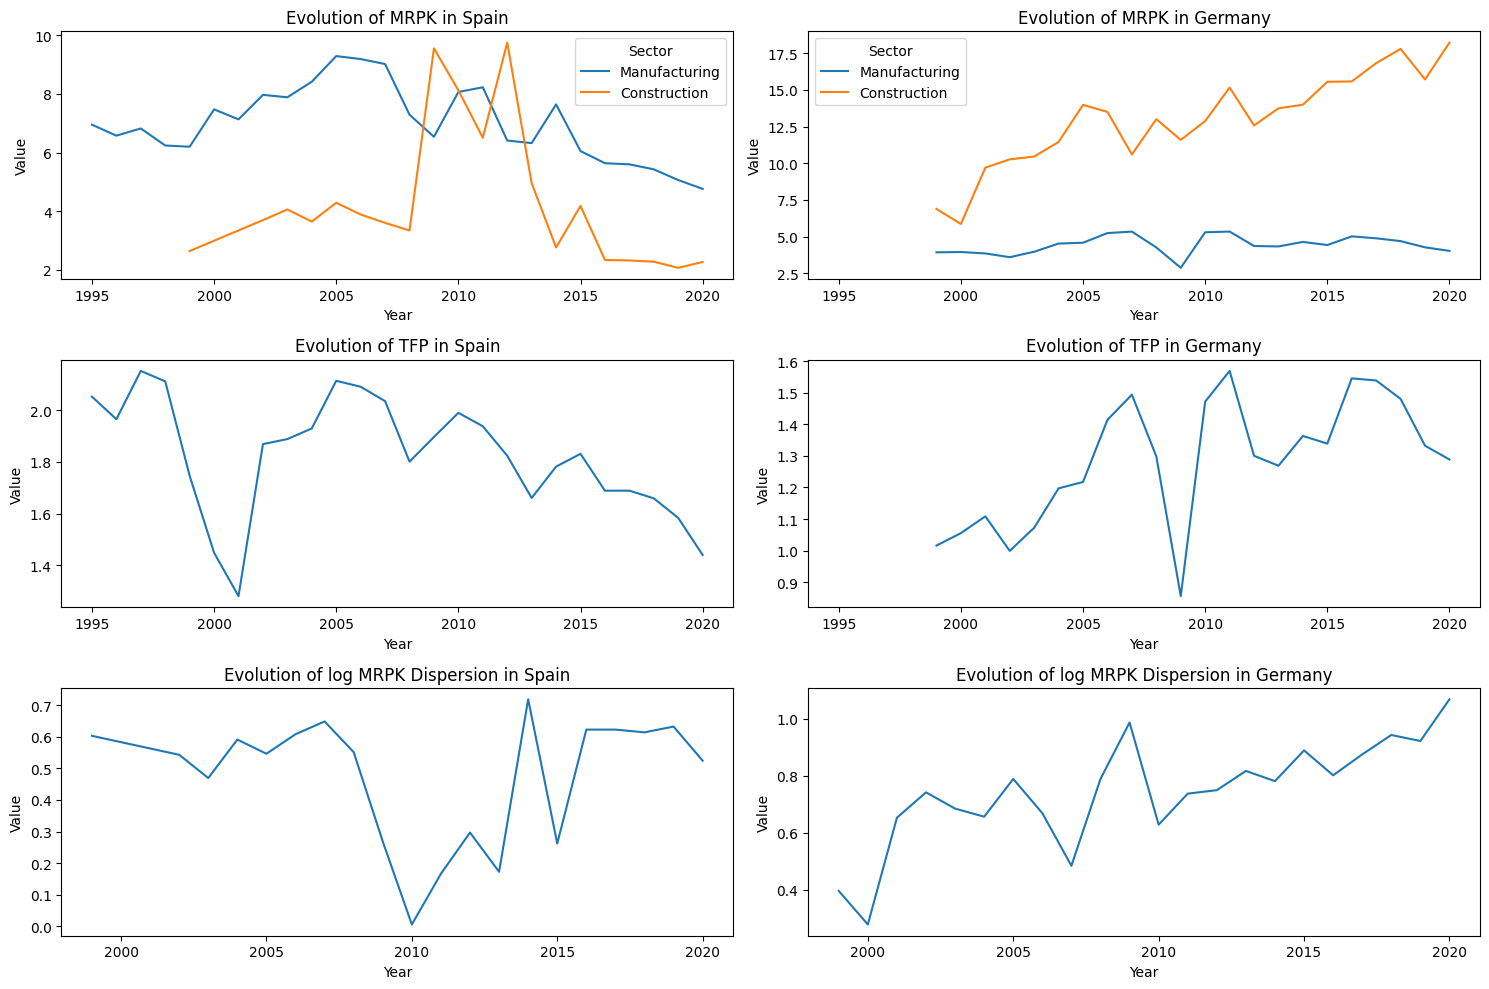

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex='row')

plot_series(data, 'ES', 'mrpk', 'Evolution of MRPK in Spain', category='Sector', ax=axes[0,0])
plot_series(tfp, 'ES', 'tfp', 'Evolution of TFP in Spain', ax=axes[1,0])
plot_series(dispersion, 'ES', 'ln mrpk', 'Evolution of log MRPK Dispersion in Spain', ax=axes[2,0])

plot_series(data, 'DE', 'mrpk', 'Evolution of MRPK in Germany', category='Sector', ax=axes[0,1])
plot_series(tfp, 'DE', 'tfp', 'Evolution of TFP in Germany', ax=axes[1,1])
plot_series(dispersion, 'DE', 'ln mrpk', 'Evolution of log MRPK Dispersion in Germany', ax=axes[2,1])

plt.tight_layout()
plt.show()
fig.savefig('spain and germany.png')

In [ ]:
#compare tfp in  before and after eurozone
beforey = 1997
aftery = 2001
before = tfp[tfp["year"] == beforey]
after  = tfp[tfp["year"] == aftery]
comparison = before.merge(after, on="country", suffixes=(f" {beforey}", f" {aftery}"))
comparison['tfp rise'] = np.where(comparison[f'tfp {aftery}'] - comparison[f'tfp {beforey}'] > 0, True, False )

comparison

,country,year 1997,revenue 1997,assets 1997,labor 1997,tfp 1997,year 2001,revenue 2001,assets 2001,labor 2001,tfp 2001,tfp rise
0,AT,1997,115493.0,8465.500,286445.0,1.382931,2001,149576.0,10173.700,314915.0,1.579133,True
1,BE,1997,160542.0,11762.200,295777.0,1.677996,2001,194315.0,13028.700,343335.0,1.778583,True
2,BG,1997,0.0,476.800,12998.0,0.000000,2001,7012.0,1853.900,14434.0,0.996346,True
3,CY,1997,2243.0,23.900,0.0,inf,2001,6024.0,175.500,10474.0,2.406106,False
4,CZ,1997,55958.0,172638.000,82535.0,0.523660,2001,72415.0,226577.000,101435.0,0.538866,True
5,DK,1997,85468.0,40044.174,190775.0,0.773706,2001,101881.0,49103.832,229016.0,0.762588,False
6,EE,1997,2393.0,220.500,5449.0,1.349410,2001,4514.0,372.400,7658.0,1.698373,True
7,ES,1997,309116.0,15859.400,470678.0,2.151546,2001,396266.0,35105.500,999128.0,1.280418,False
8,FI,1997,121282.0,5731.000,153688.0,2.495168,2001,148691.0,7950.000,201026.0,2.291090,False
9,FR,1997,560750.0,36010.000,1688320.0,1.276955,2001,684666.0,48242.000,1907922.0,1.299917,True


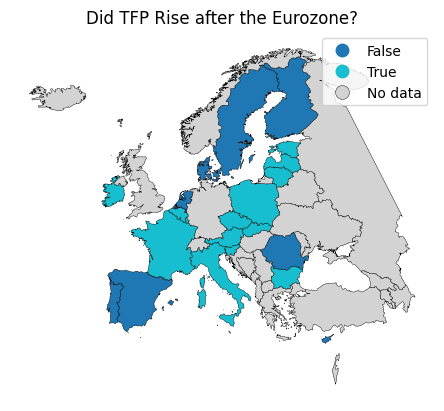

In [39]:
import geopandas as gpd

geo = gpd.read_file('europe.geojson')[['ISO2', 'geometry']]
comparison = geo.merge(comparison, left_on='ISO2', right_on='country', how='left')
comparison = comparison.set_geometry('geometry')


ax = comparison.plot(column='tfp rise', legend=True, edgecolor='black', linewidth=0.3, missing_kwds={
        "color": "lightgrey",  # color for NaN values
        "label": "No data"     # optional legend label
    })
ax.set_axis_off()
plt.title('Did TFP Rise after the Eurozone?')
plt.savefig('map.png')
plt.show()

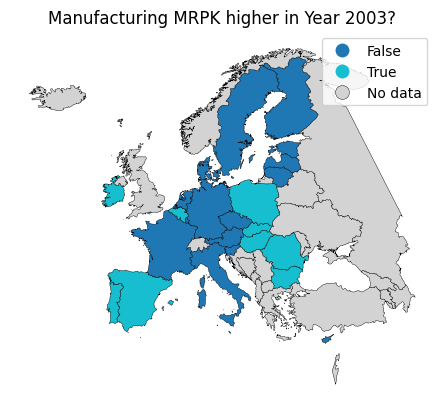

In [42]:
#compare if mrpk of construction of manufacturing is higher at year 2000
mrpk = data[data['year'] == 2003]
mrpk = mrpk.pivot(index=['country'], columns='sectorcode', values='mrpk')
mrpk['C mrpk higher'] = np.where(mrpk['C'] - mrpk['F'] > 0, True, False)

mrpk = geo.merge(mrpk,left_on='ISO2', right_on='country', how='left')
mrpk = mrpk.set_geometry('geometry')

ax = mrpk.plot(column='C mrpk higher', legend=True, edgecolor='black', linewidth=0.3, missing_kwds={
        "color": "lightgrey",  # color for NaN values
        "label": "No data"     # optional legend label
    })
ax.set_axis_off()
plt.title('Manufacturing MRPK higher in Year 2003?')
plt.savefig('map mrpk.png')
plt.show()



In [41]:
mrpk

,ISO2,geometry,C,F,C mrpk higher
0,AZ,"MULTIPOLYGON (((45.08332 39.76804, 45.26639 39...",NaN,NaN,NaN
1,AL,"POLYGON ((19.43621 41.02106, 19.45055 41.06, 1...",NaN,NaN,NaN
2,AM,"MULTIPOLYGON (((45.57305 40.63249, 45.52888 40...",NaN,NaN,NaN
3,BA,"POLYGON ((17.64984 42.88908, 17.57853 42.94382...",NaN,NaN,NaN
4,BG,"POLYGON ((27.87917 42.8411, 27.895 42.8025, 27...",3.288061,0.563951,True
5,CY,"POLYGON ((33.65262 35.3541, 33.71305 35.38194,...",10.118974,24.167213,False
6,DK,"MULTIPOLYGON (((11.51389 54.82972, 11.56444 54...",0.680531,1.320216,False
7,IE,"MULTIPOLYGON (((-9.65639 53.22222, -9.66333 53...",26.530181,NaN,False
8,EE,"MULTIPOLYGON (((23.99083 58.1, 23.97805 58.097...",4.184754,5.109296,False
9,AT,"POLYGON ((13.83361 48.7736, 13.85806 48.77055,...",5.420064,5.516194,False
